# Data ETL and exploration/preprocessing

## Loading and Exploring Data

### Guidelines

1. Load all the kcmetro text data independently and drop irrelevant information
2. Merge all data 
3. Explore data and calendar/caldates/service id in particular
4. Create function to calculate frequencies from schedule data
5. create function to map routes that match frequency target 


### Loading and Processing GTFS Data

In [2]:
###installs
%pip install folium pandas numpy geopandas shapely matplotlib folium mapclassify contextily


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
#imports
import numpy as np, pandas as pd
import folium as fl, geopandas as gpd
from shapely.geometry import LineString
from datetime import datetime

In [4]:
###loading data
trips = pd.read_csv(r'../data/KCM_data/trips.txt')
stop_times = pd.read_csv(r'../data/KCM_data/stop_times.txt')
stops = pd.read_csv(r'../data/KCM_data/stops.txt')
routes = pd.read_csv(r'../data/KCM_data/routes.txt')
cal = pd.read_csv(r'../data/KCM_data/calendar.txt')
cal_dates = pd.read_csv(r'../data/KCM_data/calendar_dates.txt')

In [5]:
###dropping unnecessary information

trips_clean = trips[['route_id','service_id','trip_id','trip_headsign', 'direction_id','block_id','shape_id']]
stop_times_clean = stop_times[['trip_id','arrival_time','departure_time','stop_id','stop_sequence','shape_dist_traveled','timepoint']]
stops_clean = stops[['stop_id','stop_code','stop_name','stop_lat','stop_lon']]
routes_clean = routes[['route_id','agency_id','route_short_name','route_desc','route_type','route_color','route_text_color']]

###cal and calendar dates are to remain unchanged until I explore the data more thoroughly 
###set the variables to the clean dataframes

trips = trips_clean
stop_times = stop_times_clean
stops = stops_clean
routes = routes_clean


###find and set types
trips.service_id = trips.service_id.astype(int)
stop_times.arrival_time = pd.to_timedelta(stop_times.arrival_time)
stop_times.departure_time = pd.to_timedelta(stop_times.departure_time)



In [6]:
###merge together data
    #merge all files one by one 

data_merged = pd.merge(trips, stop_times, how='left', on='trip_id')
data_merged = pd.merge(data_merged, stops, how='left', on='stop_id')
data_merged = pd.merge(data_merged, routes, how='left', on='route_id')

###filter to only kcm bus routes 
data_merged = data_merged.loc[data_merged.agency_id == 1].drop('agency_id', axis=1)
data_merged.head(5)

,route_id,service_id,trip_id,trip_headsign,direction_id,block_id,shape_id,arrival_time,departure_time,stop_id,...,timepoint,stop_code,stop_name,stop_lat,stop_lon,route_short_name,route_desc,route_type,route_color,route_text_color
0,100001,151056,562518401,Kinnear Seattle Center W,0,8222244,11001004,0 days 05:02:00,0 days 05:02:00,1530,...,1,1530,S Jackson St & 5th Ave S,47.599266,-122.328384,1,Kinnear - Downtown Seattle,3,FDB71A,000000
1,100001,151056,562518401,Kinnear Seattle Center W,0,8222244,11001004,0 days 05:03:43,0 days 05:03:43,1610,...,0,1610,Prefontaine Pl S & Yesler Way,47.601658,-122.329941,1,Kinnear - Downtown Seattle,3,FDB71A,000000
2,100001,151056,562518401,Kinnear Seattle Center W,0,8222244,11001004,0 days 05:05:24,0 days 05:05:24,538,...,0,538,3rd Ave & Columbia St,47.604095,-122.332504,1,Kinnear - Downtown Seattle,3,FDB71A,000000
3,100001,151056,562518401,Kinnear Seattle Center W,0,8222244,11001004,0 days 05:07:19,0 days 05:07:19,558,...,0,558,3rd Ave & Seneca St,47.607052,-122.335213,1,Kinnear - Downtown Seattle,3,FDB71A,000000
4,100001,151056,562518401,Kinnear Seattle Center W,0,8222244,11001004,0 days 05:09:00,0 days 05:09:00,575,...,1,575,3rd Ave & Pike St,47.609642,-122.337585,1,Kinnear - Downtown Seattle,3,FDB71A,000000


### Exploring Service ID's

In [7]:
###let us explore the service id to see which routes have which ids

route_servs = pd.DataFrame(data_merged.groupby('route_short_name').service_id.unique())
route_servs['unique_service_ids'] = route_servs.service_id.apply(lambda x: x.shape[0])

###put unique service ids in the front of the dataframe 
route_servs = route_servs.iloc[:,[1,0]]

route_servs.service_id.explode().value_counts()

service_id
151056    127
30098     106
34059     100
128191      5
1420        4
29348       4
24017       2
242         2
103294      1
5277        1
125810      1
63424       1
1884        1
1877        1
4015        1
6236        1
Name: count, dtype: int64

As we can see, the most popular service ids are 151056, 30098, and 34059 - corresponding to weekday,sat, and sun service

In [8]:
####find calendar dates to confirm my intuition 
cal_serv = cal

###add total weekday count and set to one for boolean comparisons 
cal_serv['weekday'] = cal_serv.drop(columns=['service_id', 'start_date','end_date', 'saturday','sunday']).apply(lambda x: any(x), axis=1)

####drop individual day of the workweek columns 
cal_serv = cal_serv.drop(columns=cal_serv.columns[1:6])

### us DF.dot to multiply 
cal_serv['dow'] = cal_serv[['saturday','sunday','weekday']].dot(cal_serv.columns[[1,2,5]]).str.lower()

###find services that are weekday, weekend, or special service
cal_serv = cal_serv.drop(columns=['saturday','sunday','weekday'])
cal_serv.dow = cal_serv.dow.replace('', 'special')

###make service id an int
cal_serv.service_id = cal_serv.service_id.astype(int)

###save service ids by dow for further exploration
cal_serv.to_csv('../data/serv_dow.csv')

###display 
cal_serv.head(8)


,service_id,start_date,end_date,dow
0,103294,20260902,20270326,special
1,125810,20260902,20270326,special
2,128191,20260902,20270326,special
3,1420,20260907,20260907,weekday
4,145779,20260831,20270326,weekday
5,147726,20260831,20270326,weekday
6,149182,20260831,20270326,weekday
7,151056,20260831,20270326,weekday


### Frequency Calculations/Functions and Verification

We will explore the data by using various methods to try to calculate frequency and then we will validate. 

In [ ]:
##lets use groupby in pandas to filter/sort the data we desire and limit it to a single stop + dir + service_id 

data_merged = data_merged.sort_values(by=['stop_id', 'arrival_time'])

####group by stop id and sort by time of arrival 

data_merged['prev_depart'] = data_merged.groupby(['route_id', 'service_id', 'direction_id', 'stop_id']).departure_time.shift(1)
data_merged['gap'] = data_merged['departure_time'] - data_merged['prev_depart']
route_freq = pd.DataFrame(data_merged.groupby('route_short_name').gap.mean().sort_values(ascending=True))

##group by stop sequence and sort by time of arrival

data_merged['prev_depart'] = data_merged.groupby(['route_id', 'service_id', 'direction_id', 'stop_sequence']).departure_time.shift(1)
data_merged['gap'] = data_merged['departure_time'] - data_merged['prev_depart']
route_freq['by_sequence'] = pd.DataFrame(data_merged.groupby('route_short_name').gap.mean().sort_values(ascending=True))

### we will now find the differences between sorting by stop sequence and sorting by stop_id 

route_freq['dif'] = np.abs(route_freq['by_sequence'] - route_freq['gap'])

###display the differences based on calculation type. 
###it would seem sensible to me that stop id would be the better variable to use as lines can start at various stop ids first (changing stop seq no.)

route_freq.loc[route_freq.dif >= pd.Timedelta(seconds=1)].sort_values('dif', ascending=False)[['gap', 'by_sequence','dif']]

,gap,by_sequence,dif
route_short_name,,,
119,0 days 02:19:31.710144,0 days 01:40:53.666666,0 days 00:38:38.043478
14,0 days 00:24:34.979872,0 days 00:11:04.577685,0 days 00:13:30.402187
124,0 days 00:26:58.069147,0 days 00:13:53.885855,0 days 00:13:04.183292
1,0 days 00:23:45.030561,0 days 00:15:03.063032,0 days 00:08:41.967529
4,0 days 00:24:19.152034,0 days 00:16:15.288281,0 days 00:08:03.863753
Trailhead Direct Mt. Si,0 days 00:36:19.740458,0 days 00:29:04.461832,0 days 00:07:15.278626
3,0 days 00:30:32.101589,0 days 00:23:51.281728,0 days 00:06:40.819861
33,0 days 00:37:48.886466,0 days 00:31:11.014526,0 days 00:06:37.871940
Easy Loop,0 days 00:41:39.775280,0 days 00:47:43.636363,0 days 00:06:03.861083


### Frequency Function

In [16]:
###function for calculating freqeuncy of schedule data 
def freq_calc(df, label='departure_time', start_hr=0, end_hr=30, dow='all'):
    ###add function call for function that filters data based on time and dow 

    ### only locate columns we need for the calculations to save memory and increase run speed
    df_lite = df[['route_id','trip_id','stop_id','route_short_name', 'service_id','direction_id', label]]

    start_time = pd.Timedelta(hours=start_hr)
    end_time = pd.Timedelta(hours=end_hr)
    ###convert departure_time to timedelta
    df_lite.departure_time = pd.to_timedelta(df_lite.departure_time)
    ###restrict to time range
    df_lite = df_lite.loc[(df_lite.departure_time >= start_time) & (df_lite.departure_time <= end_time)]

    ####group by stop id and sort by time of arrival 
    df_lite['prev_depart'] = df_lite.groupby(['route_id', 'service_id', 'direction_id', 'stop_id']).departure_time.shift(1)
    df_lite['gap'] = df_lite['departure_time'] - df_lite['prev_depart']

    ###calculate frequencies, eventually calculate frequencies with mean, median, max, min, first, last, etc. 
    route_freq = pd.DataFrame(df_lite.groupby('route_short_name').gap.mean().sort_values(ascending=True))

    return route_freq

    

### Data Filter Function

In [22]:
def filter_trips(df, time_col='departure_time', start_hr=0, end_hr=30, dow='all'):
    #set time col and filters to timedelta 
    df[time_col] = pd.to_timedelta(df[time_col])
    start_hr = pd.Timedelta(hours=start_hr)
    end_hr = pd.Timedelta(hours=end_hr)

    ###filtered based on hours of day 
    df = df.loc[(df[time_col]>= start_hr) & (df[time_col] <= end_hr)]

    ##filter based on service dow 
    dow_data = pd.read_csv('../data/serv_dow.csv')[['service_id','dow']]
    
    if dow != 'all':
        dow_data = dow_data.loc[dow_data.dow == dow]
        df = df.loc[df.service_id.isin(dow_data.service_id)]
        
    return df


### Displaying various route metrics along with filtered frequencies 

In [31]:
###find data from rapidrides to compare/validate
rr_data = data_merged.loc[data_merged.route_short_name.str.match(r'\w Line')]
rr_freq = route_freq.loc[route_freq.index.str.match(r'\w Line')]

###find the frequencies of only the rapidrides 
filter_trips(rr_data, start_hr=16, end_hr=20,dow='saturday').sort_values(['trip_id','departure_time'])[['route_short_name','gap']]

,route_short_name,gap
784341,B Line,0 days 00:15:00
784342,B Line,0 days 00:15:00
784343,B Line,0 days 00:15:00
784344,B Line,0 days 00:15:00
784345,B Line,0 days 00:15:00
...,...,...
876253,E Line,0 days 00:10:00
876254,E Line,0 days 00:10:00
876255,E Line,0 days 00:10:00
876256,E Line,0 days 00:10:00


## Mapping Processing and Exploration

In [13]:
#load and sort shape values
shapes = pd.read_csv('../data/KCM_data/shapes.txt').sort_values(['shape_id','shape_pt_sequence'])

###create shapely linestring shapes per shape id which corresponds to trip id 
lines = (
    shapes.groupby('shape_id')
    .apply(lambda x: LineString(zip(x.shape_pt_lon,x.shape_pt_lat)))
    .reset_index(name='geometry')
)
lines.to_csv('../data/geometry.csv')

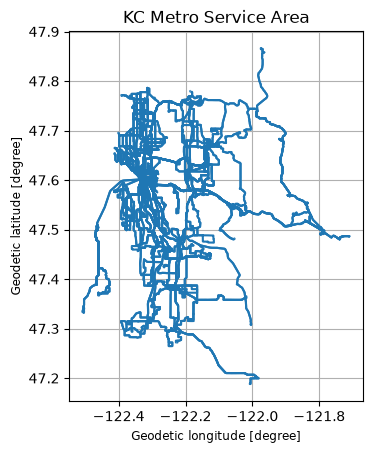

In [14]:
import matplotlib.pyplot as plt, contextily
###display all routes to see extent of service area 
geo_df = gpd.GeoDataFrame(lines, crs='EPSG:4326')
geo_df.plot()
plt.title('KC Metro Service Area')
plt.grid(True)